# Publication Figures

Curated, publication-quality figures for the manuscript *"Comparative Genomic
and Explainable Machine Learning Analysis of Compensatory Mutations Associated
with Multidrug-Resistance in African Mycobacterium tuberculosis"*.

This notebook builds 5 main figures from this project's real, already-verified
output files (Steps 1, 2, 4, 5, 11) - it does not recompute any of the
underlying statistics, models, or evidence tiers established earlier in this
project, only re-renders them to a consistent, publication-ready style.

**Inputs required in this directory:**
- `obj1_fisher_all_variants.csv` (Step 2 - genome-wide screen, all 94,583 variants)
- `X_array.npy`, `y_mdr_array.npy` (Step 1 - for the ROC curve figure)
- `obj2_shap_top100_annotated.csv` (Step 5)
- `obj_final_master_evidence_table.csv` (Step 11)

**A note on Figure 3 (ROC curves):** the curves are computed fresh, on a real
80/20 stratified held-out split of this project's actual data - genuine
held-out evaluation, not in-sample prediction (confirmed while building this:
in-sample XGBoost AUC is a misleadingly high 0.9997, vs. the real
cross-validated 0.9937). EBM's fresh fit uses reduced complexity (1,000
features via chi2, 1 bag, no interaction terms) purely because the full Step 6
configuration (5,000 features, 4 bags, 5 interaction terms) was too slow to
refit interactively - Step 6's own analysis remains the authoritative EBM
result. The single-split AUCs shown here are illustrative of relative model
ranking; the cross-validated AUC (mean ± SD across 5 folds), as already
established and reported in the Phase 4A/4C reports, remains the number to cite
in text.


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import Normalize

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0.8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

NAVY, TEAL, CORAL = "#1F4E5F", "#2E6E7E", "#C0392B"
GREY_BG, TEAL_BG, CORAL_BG = "#F4F6F7", "#EAF3EE", "#FDF0EE"

HOME    = os.path.expanduser("~")
BASE    = os.path.join(HOME, "tb_pipeline")
ML_OUT  = os.path.join(BASE, "ml_outputs")
STEP1   = os.path.join(ML_OUT, "step1_dataset")
STEP2   = os.path.join(ML_OUT, "step2_comparative")
STEP5   = os.path.join(ML_OUT, "step5_shap")
STEP6   = os.path.join(ML_OUT, "step6_ebm")
STEP8   = os.path.join(ML_OUT, "step8_lineage")
STEP9   = os.path.join(ML_OUT, "step9_conservation")
STEP10  = os.path.join(ML_OUT, "step10_structural")
STEP11  = os.path.join(ML_OUT, "step11_pub_figures")
STEP12  = os.path.join(ML_OUT, "step12_publication_figures")
os.makedirs(STEP12, exist_ok=True)

print(f"Step 1 input directory:  {STEP1}")
print(f"Step 2 input directory:  {STEP2}")
print(f"Step 5 input directory:  {STEP5}")
print(f"Step 6 input directory:  {STEP6}")
print(f"Step 8 input directory:  {STEP8}")
print(f"Step 9 input directory:  {STEP9}")
print(f"Step 10 input directory: {STEP10}")
print(f"Step 11 input directory: {STEP11}")
print(f"Step 12 output directory:{STEP12}")


Step 1 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step1_dataset
Step 2 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step2_comparative
Step 5 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step5_shap
Step 6 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm
Step 8 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step8_lineage
Step 9 input directory:  /home/sukhjot/tb_pipeline/ml_outputs/step9_conservation
Step 10 input directory: /home/sukhjot/tb_pipeline/ml_outputs/step10_structural
Step 11 input directory: /home/sukhjot/tb_pipeline/ml_outputs/step11_pub_figures
Step 12 output directory:/home/sukhjot/tb_pipeline/ml_outputs/step12_publication_figures


## Figure 1 - Workflow Overview

A schematic of the three objectives and eleven steps this project comprises, ending in Step 11's evidence-tiered integration.

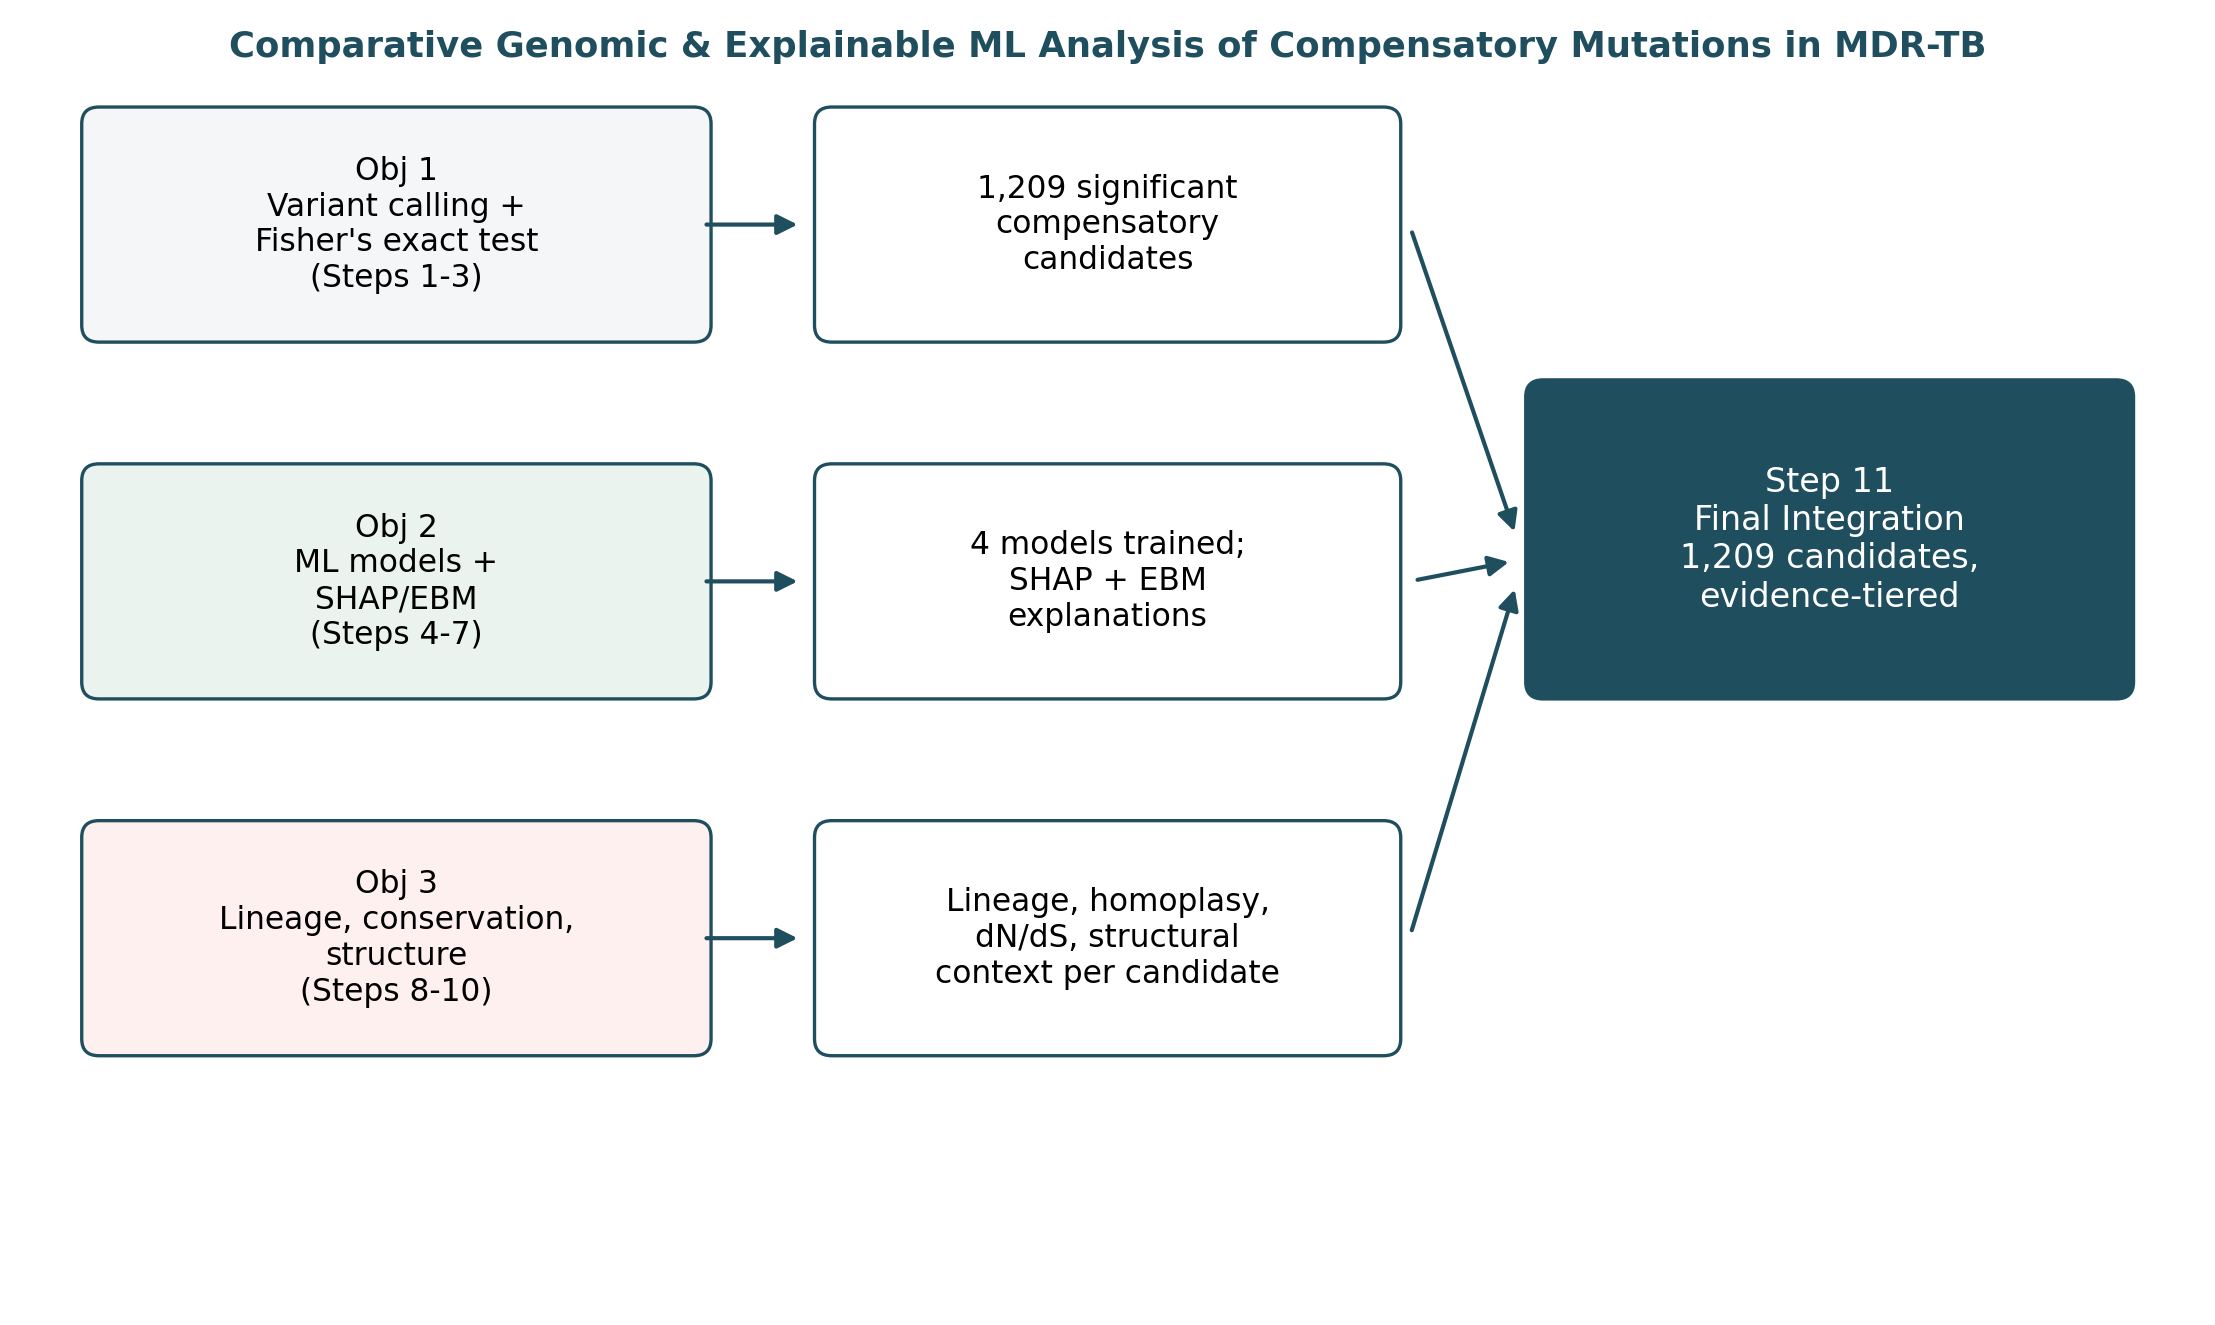

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor="black", fontsize=7.5):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06,rounding_size=0.08",
                        facecolor=facecolor, edgecolor=NAVY, linewidth=0.8)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize, color=textcolor)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                  mutation_scale=10, color=NAVY, linewidth=1.0))

box(0.3, 4.6, 2.8, 1.0, "Obj 1\nVariant calling +\nFisher's exact test\n(Steps 1-3)", GREY_BG)
box(0.3, 2.9, 2.8, 1.0, "Obj 2\nML models +\nSHAP/EBM\n(Steps 4-7)", TEAL_BG)
box(0.3, 1.2, 2.8, 1.0, "Obj 3\nLineage, conservation,\nstructure\n(Steps 8-10)", CORAL_BG)

arrow(3.1, 5.1, 3.6, 5.1); arrow(3.1, 3.4, 3.6, 3.4); arrow(3.1, 1.7, 3.6, 1.7)

box(3.7, 4.6, 2.6, 1.0, "1,209 significant\ncompensatory\ncandidates", "white")
box(3.7, 2.9, 2.6, 1.0, "4 models trained;\nSHAP + EBM\nexplanations", "white")
box(3.7, 1.2, 2.6, 1.0, "Lineage, homoplasy,\ndN/dS, structural\ncontext per candidate", "white")

arrow(6.4, 5.1, 6.9, 3.6); arrow(6.4, 3.4, 6.9, 3.5); arrow(6.4, 1.7, 6.9, 3.4)

box(7.0, 2.9, 2.7, 1.4, "Step 11\nFinal Integration\n1,209 candidates,\nevidence-tiered", NAVY,
    textcolor="white", fontsize=8)

ax.text(5.0, 5.9, "Comparative Genomic & Explainable ML Analysis of Compensatory Mutations in MDR-TB",
        ha="center", fontsize=8.5, weight="bold", color=NAVY)

plt.tight_layout()
plt.savefig(os.path.join(STEP12, "fig1_workflow_overview.png"))
plt.show()


## Figure 2 - Genome-Wide Association Screen (Volcano Plot)

All 94,583 variants tested in Step 2's Fisher's exact test, coloured by gene category. A Haldane-Anscombe correction (+0.5 to every 2x2 cell) is applied before the log2(odds ratio) transform so every point is shown, including the ~31% of variants with a zero-count cell that would otherwise be undefined on a log scale.

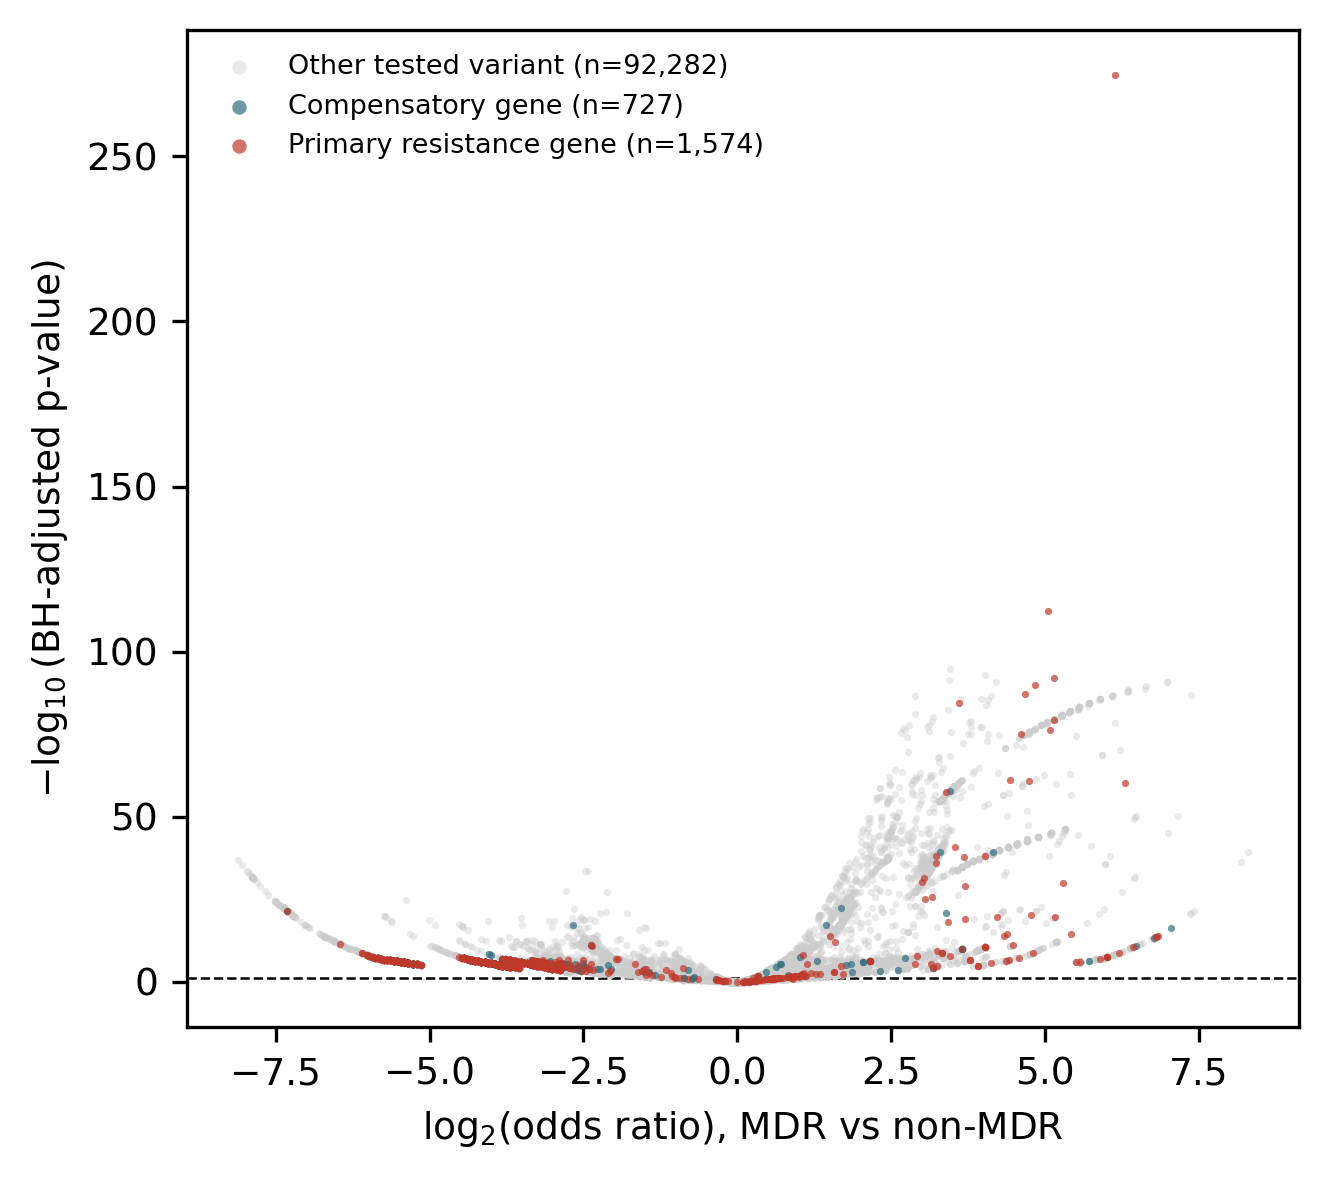

In [9]:
df = pd.read_csv(os.path.join(STEP2, "obj1_fisher_all_variants.csv"))

a = df["mdr_alt_count"] + 0.5
b = df["mdr_ref_count"] + 0.5
c = df["susc_alt_count"] + 0.5
d = df["susc_ref_count"] + 0.5
df["log2_or"] = np.log2((a * d) / (b * c))

def categorize(row):
    if row["is_primary_DR_gene"]:
        return "Primary resistance gene"
    if row["is_compensatory_gene"]:
        return "Compensatory gene"
    return "Other tested variant"
df["category"] = df.apply(categorize, axis=1)

fig, ax = plt.subplots(figsize=(4.5, 4))
colors = {"Other tested variant": "#cccccc", "Compensatory gene": TEAL, "Primary resistance gene": CORAL}
for cat in ["Other tested variant", "Compensatory gene", "Primary resistance gene"]:
    mask = df["category"] == cat
    ax.scatter(df.loc[mask, "log2_or"], df.loc[mask, "neg_log10_padj"], s=3,
               alpha=0.4 if cat == "Other tested variant" else 0.7,
               color=colors[cat], label=f"{cat} (n={mask.sum():,})", linewidths=0, rasterized=True)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.6, zorder=0)
ax.set_xlabel("log$_2$(odds ratio), MDR vs non-MDR")
ax.set_ylabel(r"$-\log_{10}$(BH-adjusted p-value)")
ax.legend(fontsize=6.5, frameon=False, loc="upper left", markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "fig2_volcano_plot.png"))
plt.show()


## Figure 3 - Model Performance (ROC Curves)

Fresh fit of all 4 models on a real 80/20 stratified held-out split (see the notebook-level note above on why this, rather than the saved cross-validated numbers, is used for the curve shape specifically).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scipy import sparse
import xgboost as xgb
from interpret.glassbox import ExplainableBoostingClassifier

class ToFloat32(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return X.astype(np.float32)

X = np.load(os.path.join(STEP1, "X_array.npy"))
y = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
Xs = sparse.csr_matrix(X)   # matrix is ~1.4% dense -- sparse representation is essential for memory
del X

X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=42)

roc_data = {}

lr = Pipeline([("chi2", SelectKBest(chi2, k=5000)), ("f32", ToFloat32()),
               ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])
lr.fit(X_train, y_train)
roc_data["Logistic Regression"] = lr.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=20, max_features="sqrt",
                             min_samples_leaf=5, min_samples_split=10,
                             class_weight="balanced", n_jobs=2, random_state=42)
rf.fit(X_train, y_train)
roc_data["Random Forest"] = rf.predict_proba(X_test)[:, 1]

xgbc = xgb.XGBClassifier(n_estimators=300, max_depth=6, tree_method="hist",
                          eval_metric="logloss", random_state=42, n_jobs=2)
xgbc.fit(X_train, y_train)
roc_data["XGBoost"] = xgbc.predict_proba(X_test)[:, 1]

# Reduced complexity for EBM specifically -- see the notebook intro's note.
chi2_sel = SelectKBest(chi2, k=1000)
X_train_sel = chi2_sel.fit_transform(X_train, y_train).toarray().astype(np.float32)
X_test_sel = chi2_sel.transform(X_test).toarray().astype(np.float32)
ebm = ExplainableBoostingClassifier(outer_bags=1, interactions=0, n_jobs=1, random_state=42, max_rounds=2000)
ebm.fit(X_train_sel, y_train)
roc_data["EBM GlassBox"] = ebm.predict_proba(X_test_sel)[:, 1]

for name, proba in roc_data.items():
    print(f"{name}: held-out AUC = {roc_auc_score(y_test, proba):.4f}")


Logistic Regression: held-out AUC = 0.9912
Random Forest: held-out AUC = 0.9718
XGBoost: held-out AUC = 0.9947
EBM GlassBox: held-out AUC = 0.9904


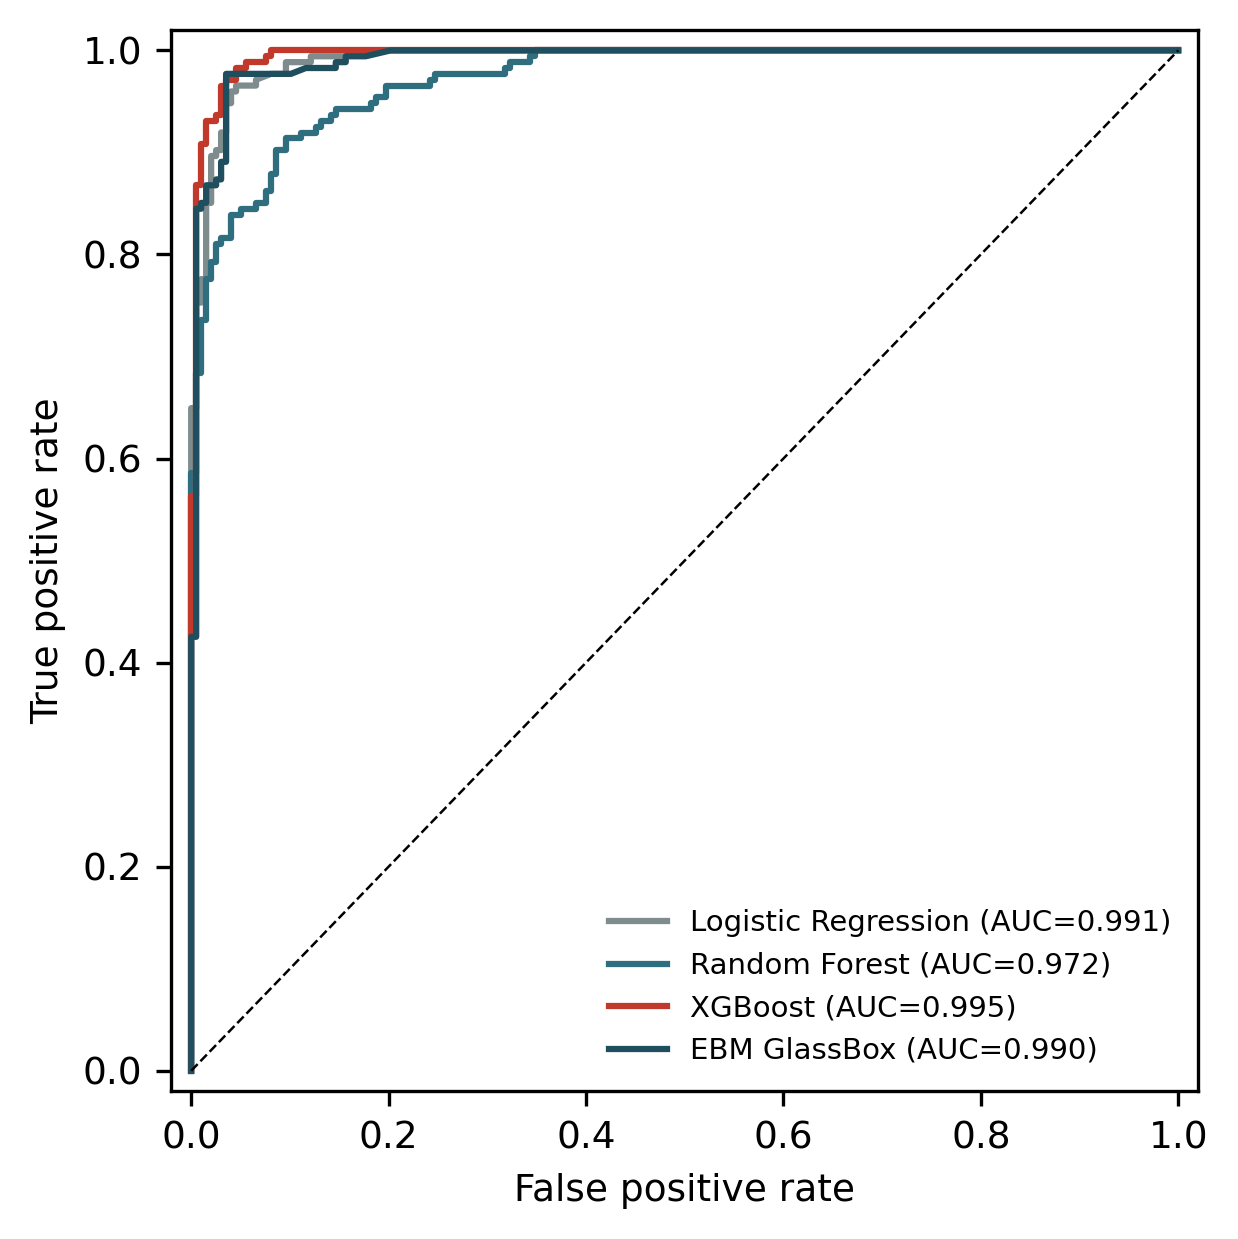

In [11]:
colors_roc = {"Logistic Regression": "#7f8c8d", "Random Forest": TEAL,
              "XGBoost": CORAL, "EBM GlassBox": NAVY}

fig, ax = plt.subplots(figsize=(4.2, 4.2))
for name in ["Logistic Regression", "Random Forest", "XGBoost", "EBM GlassBox"]:
    fpr, tpr, _ = roc_curve(y_test, roc_data[name])
    ax.plot(fpr, tpr, color=colors_roc[name], linewidth=1.5,
            label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.6)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(fontsize=7, frameon=False, loc="lower right")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "fig3_roc_curves.png"))
plt.show()


## Figure 4 - Explainability Summary (Top 20 SHAP Features)

The 20 most predictive variants by mean |SHAP value| (XGBoost), coloured by gene category.

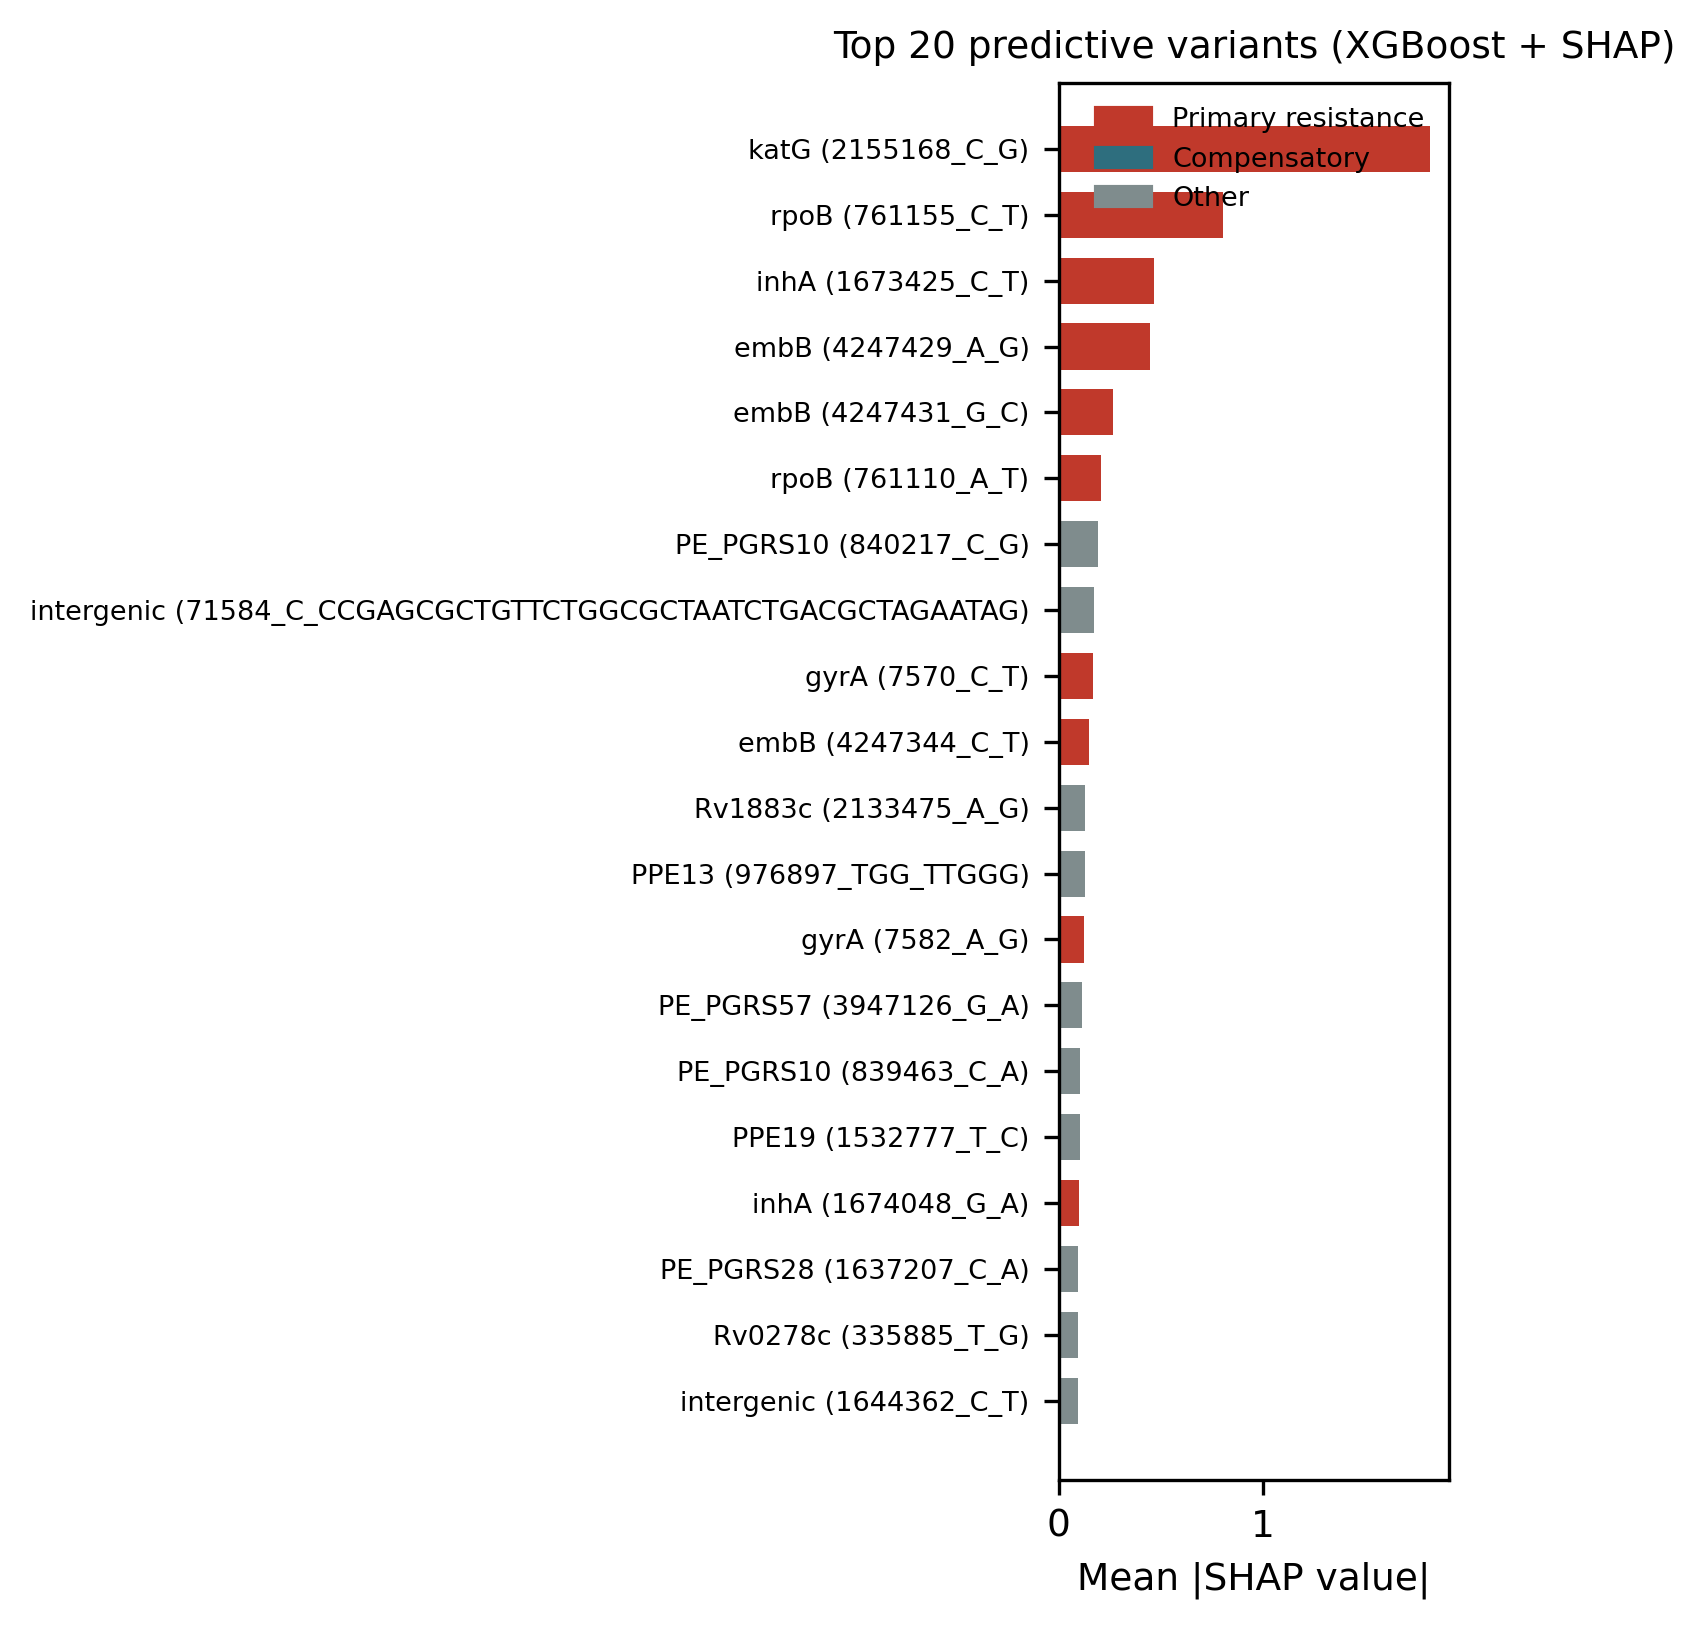

In [12]:
shap100 = pd.read_csv(os.path.join(STEP5, "obj2_shap_top100_annotated.csv"))
top20 = shap100.sort_values("rank").head(20).copy()
top20["label"] = top20["gene"] + " (" + top20["variant_id"].str.replace("Chromosome_", "") + ")"

def cat(row):
    if row["is_primary_DR"]:
        return "Primary resistance"
    if row["is_compensatory"]:
        return "Compensatory"
    return "Other"
top20["category"] = top20.apply(cat, axis=1)
colors_cat = {"Primary resistance": CORAL, "Compensatory": TEAL, "Other": "#7f8c8d"}

fig, ax = plt.subplots(figsize=(5, 5.5))
y_pos = np.arange(len(top20))[::-1]
ax.barh(y_pos, top20["mean_abs_shap"], color=[colors_cat[c] for c in top20["category"]], height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20["label"], fontsize=6.5)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 20 predictive variants (XGBoost + SHAP)", fontsize=9)
ax.set_ylim(-1.2, len(top20))

handles = [Patch(color=colors_cat[c], label=c) for c in ["Primary resistance", "Compensatory", "Other"]]
ax.legend(handles=handles, fontsize=6.5, frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "fig4_shap_summary.png"))
plt.show()


## Figure 5 - Integrated Multi-Layer Evidence (Objective 3 Capstone)

The genuinely new figure this project's Step 11 integration enables: the top 15 candidates by statistical significance (from the 'convergent' evidence tiers), plus the one flagged anomaly, shown across all four evidence layers side by side.

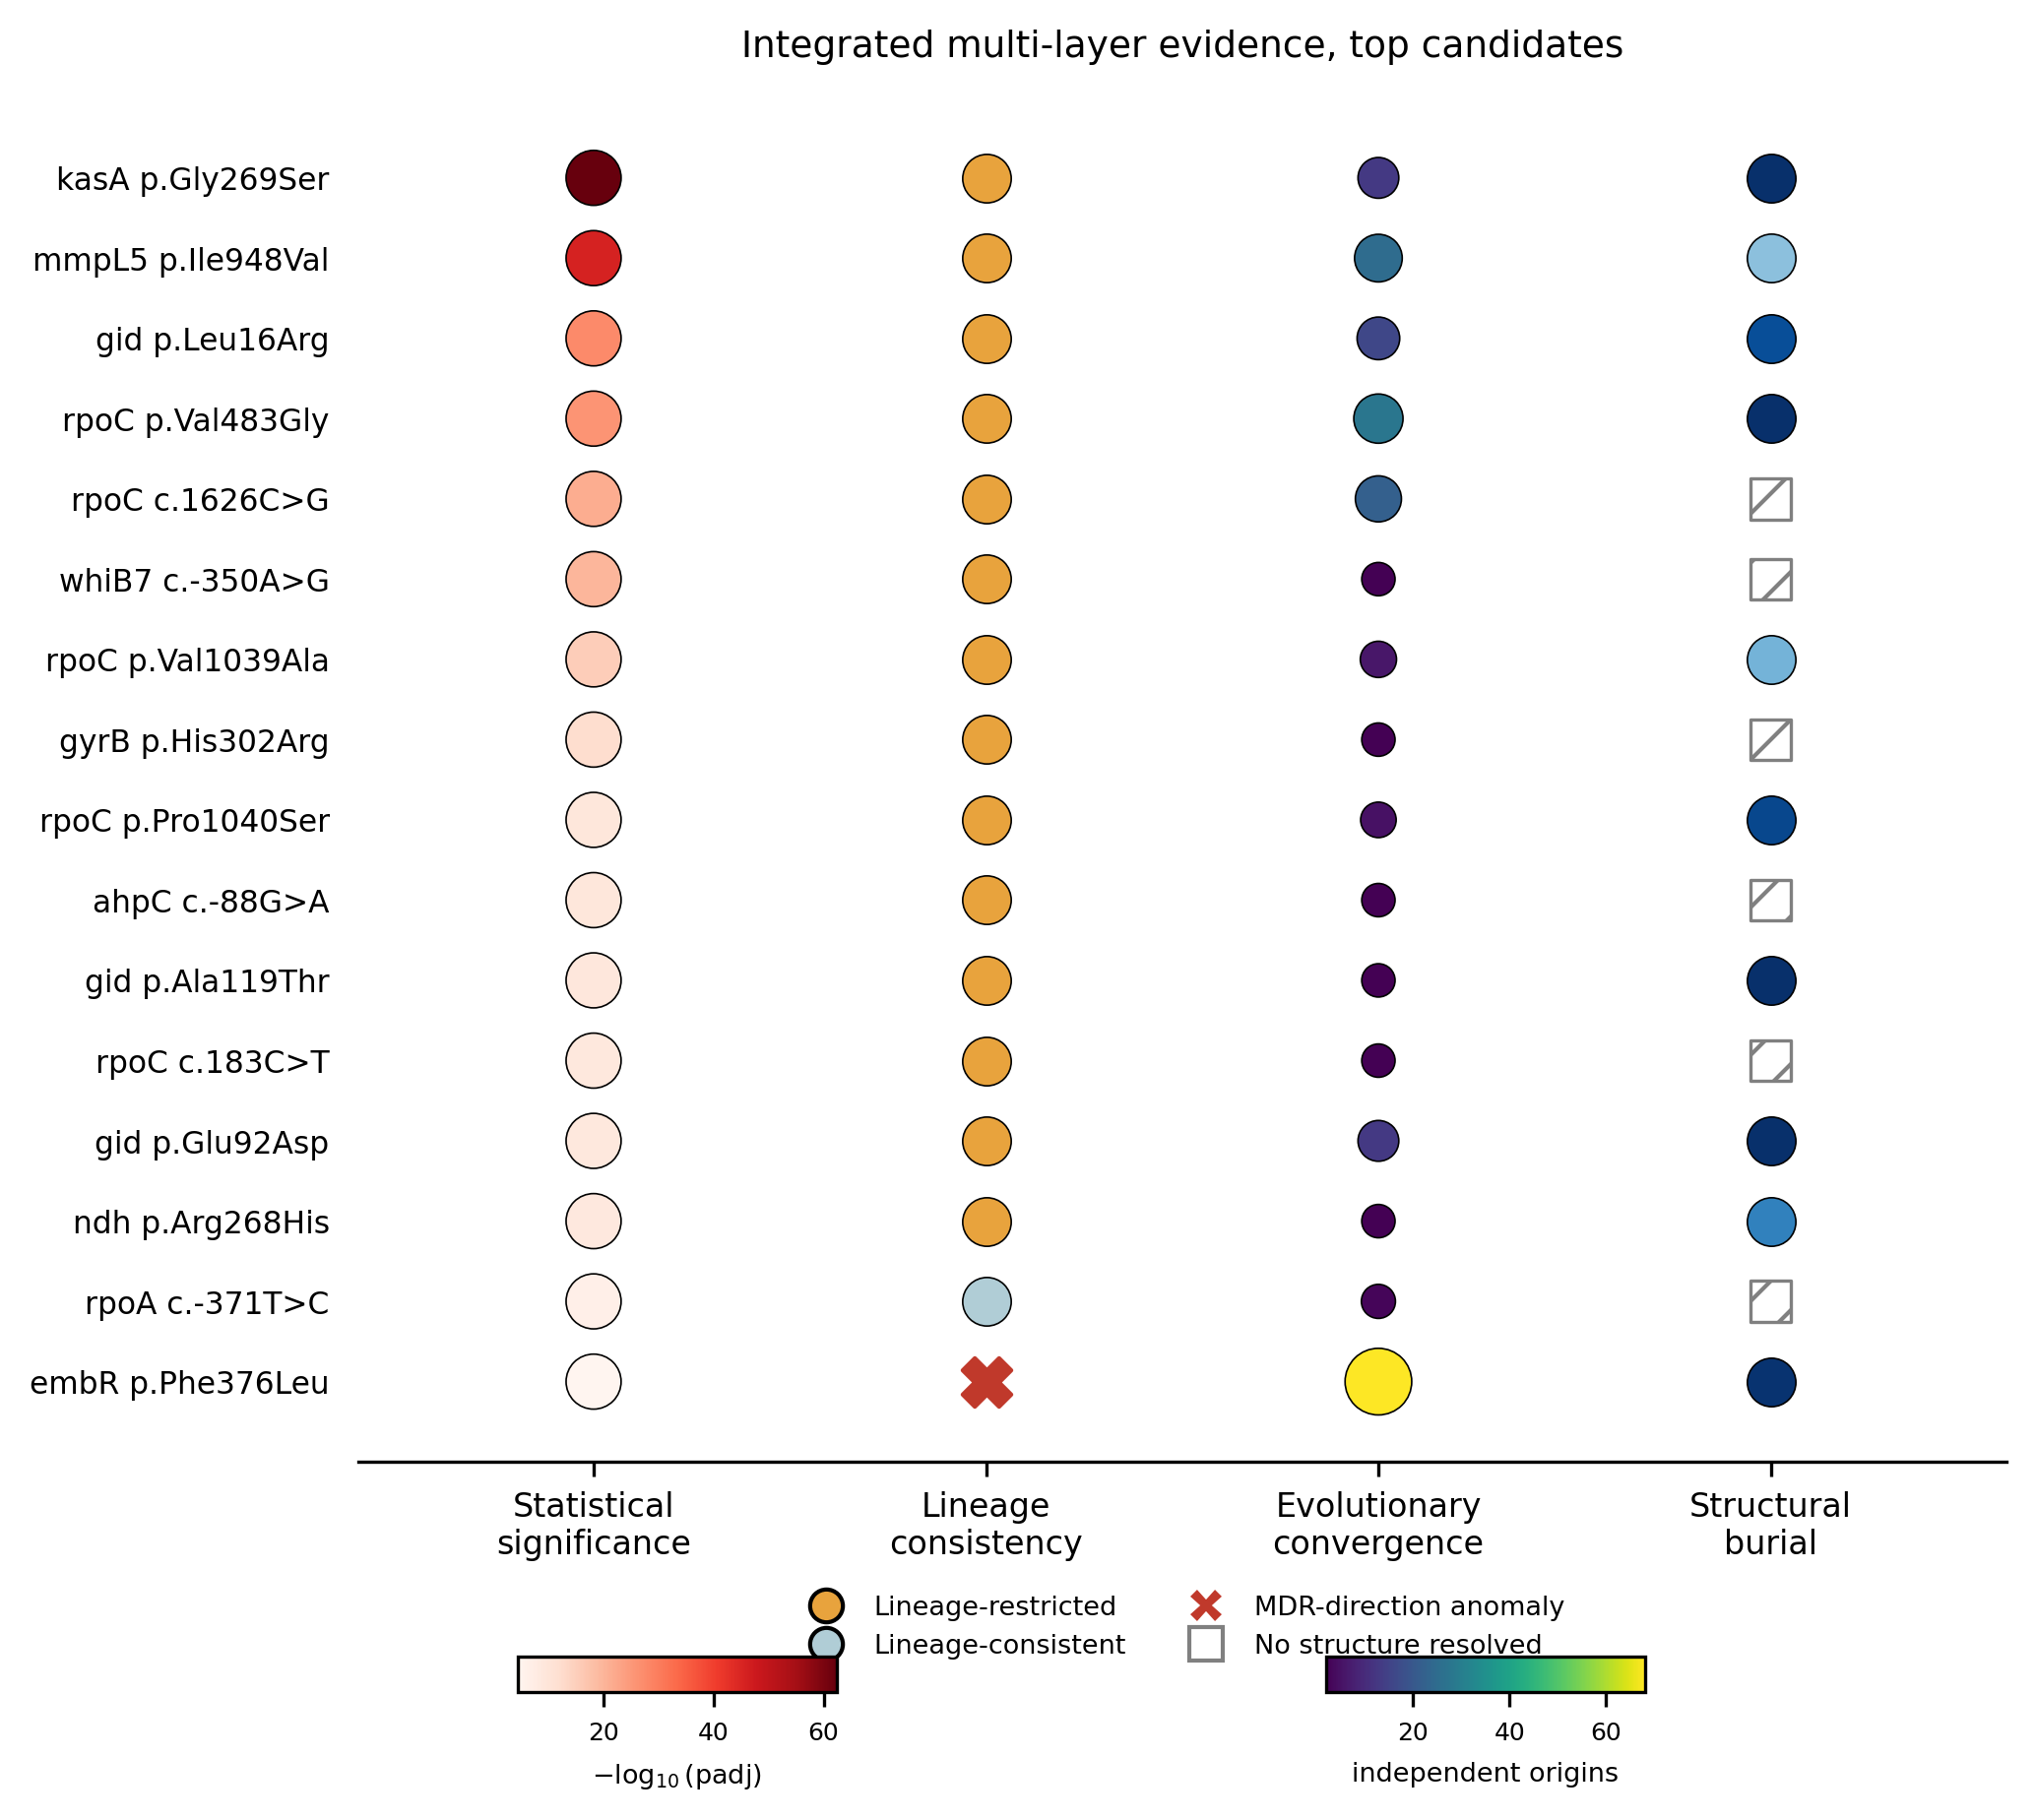

In [15]:
master = pd.read_csv(os.path.join(STEP11, "obj_final_master_evidence_table.csv"))
strong = master[master["evidence_tier"].isin(
    ["Strong, convergent, lineage-consistent", "Convergent but lineage-restricted"]
)].sort_values("step2_padj_BH").head(15)
anomaly = master[master["evidence_tier"] == "Flagged anomaly - requires caveat"]
top = pd.concat([strong, anomaly]).drop_duplicates("variant_id").reset_index(drop=True)
top["label"] = top["gene"] + " " + top["change"]
n = len(top)

fig, ax = plt.subplots(figsize=(7.2, 6))
col_x = {"Statistical\nsignificance": 0, "Lineage\nconsistency": 1,
         "Evolutionary\nconvergence": 2, "Structural\nburial": 3}
y_pos = np.arange(n)[::-1]

neglog_p = -np.log10(top["step2_padj_BH"].clip(lower=1e-300))
norm1 = Normalize(vmin=neglog_p.min(), vmax=neglog_p.max())
sc1 = ax.scatter([col_x["Statistical\nsignificance"]]*n, y_pos, c=neglog_p, cmap="Reds",
                  norm=norm1, s=180, edgecolors="black", linewidths=0.4)

for i, row in top.iterrows():
    yi = y_pos[i]
    if row["evidence_tier"] == "Flagged anomaly - requires caveat":
        ax.scatter(col_x["Lineage\nconsistency"], yi, marker="X", s=140, color=CORAL)
    elif row["step8_lineage_restricted"]:
        ax.scatter(col_x["Lineage\nconsistency"], yi, marker="o", s=140, color="#E8A33D",
                   edgecolors="black", linewidths=0.4)
    else:
        ax.scatter(col_x["Lineage\nconsistency"], yi, marker="o", s=140, color="#B0CDD6",
                   edgecolors="black", linewidths=0.4)

origins = top["step9_n_independent_origins"].fillna(0)
norm3 = Normalize(vmin=origins.min(), vmax=origins.max())
sc3 = ax.scatter([col_x["Evolutionary\nconvergence"]]*n, y_pos, c=origins, cmap="viridis",
                  norm=norm3, s=60 + origins*3, edgecolors="black", linewidths=0.4)

for i, row in top.iterrows():
    yi = y_pos[i]
    if pd.isna(row["step10_rsa"]):
        ax.scatter(col_x["Structural\nburial"], yi, marker="s", s=100, color="white",
                   edgecolors="gray", linewidths=0.8, hatch="//")
    else:
        ax.scatter(col_x["Structural\nburial"], yi, marker="o", s=140,
                   color=plt.cm.Blues_r(row["step10_rsa"]), edgecolors="black", linewidths=0.4)

ax.set_xticks(list(col_x.values()))
ax.set_xticklabels(list(col_x.keys()), fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top["label"], fontsize=7.5)
ax.set_xlim(-0.6, 3.6)
ax.set_ylim(-1, n)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_title("Integrated multi-layer evidence, top candidates", fontsize=9, pad=10)

cax1 = fig.add_axes([0.20, -0.02, 0.15, 0.02])
cb1 = fig.colorbar(sc1, cax=cax1, orientation="horizontal")
cb1.set_label(r"$-\log_{10}$(padj)", fontsize=6.5)
cb1.ax.tick_params(labelsize=6)

cax3 = fig.add_axes([0.58, -0.02, 0.15, 0.02])
cb3 = fig.colorbar(sc3, cax=cax3, orientation="horizontal")
cb3.set_label("independent origins", fontsize=6.5)
cb3.ax.tick_params(labelsize=6)

legend_elements = [
    mlines.Line2D([0], [0], marker="o", color="w", markerfacecolor="#E8A33D", markeredgecolor="black", markersize=8, label="Lineage-restricted"),
    mlines.Line2D([0], [0], marker="o", color="w", markerfacecolor="#B0CDD6", markeredgecolor="black", markersize=8, label="Lineage-consistent"),
    mlines.Line2D([0], [0], marker="X", color="w", markerfacecolor=CORAL, markersize=9, label="MDR-direction anomaly"),
    mlines.Line2D([0], [0], marker="s", color="w", markerfacecolor="white", markeredgecolor="gray", markersize=8, label="No structure resolved"),
]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=6.5, frameon=False)

plt.savefig(os.path.join(STEP12, "fig5_integrated_evidence.png"))
plt.show()


## Summary

All 5 main figures 
- `fig1_workflow_overview.png`
- `fig2_volcano_plot.png`
- `fig3_roc_curves.png`
- `fig4_shap_summary.png`
- `fig5_integrated_evidence.png`

Figure 5 is the one genuinely new figure among these - it doesn't exist in any earlier step's own output, and is the direct payoff of Step 11's integration work.

---
# Supplementary Figures

Four supplementary figures, re-rendered in the same publication style as the main
figures, from real output already produced in Steps 8, 6, and 10 (S1, S3), Step 9
(S2), and Step 10 (S4) - no new analysis, just consistent re-styling plus one
genuinely new distribution plot (S4) that didn't exist as a figure before.

**Inputs required:**
- `obj3_lineage_distribution.csv` (Step 8)
- `obj3_step9_gene_dNdS.csv` (Step 9)
- `obj2_ebm_interactions_annotated.csv` (Step 6)
- `obj3_step10_structural_context.csv` (Step 10)


## Figure S1 - Lineage Restriction Heatmap

Per-lineage carriage percentage for the 20 most significantly lineage-restricted compensatory candidates (Step 8).

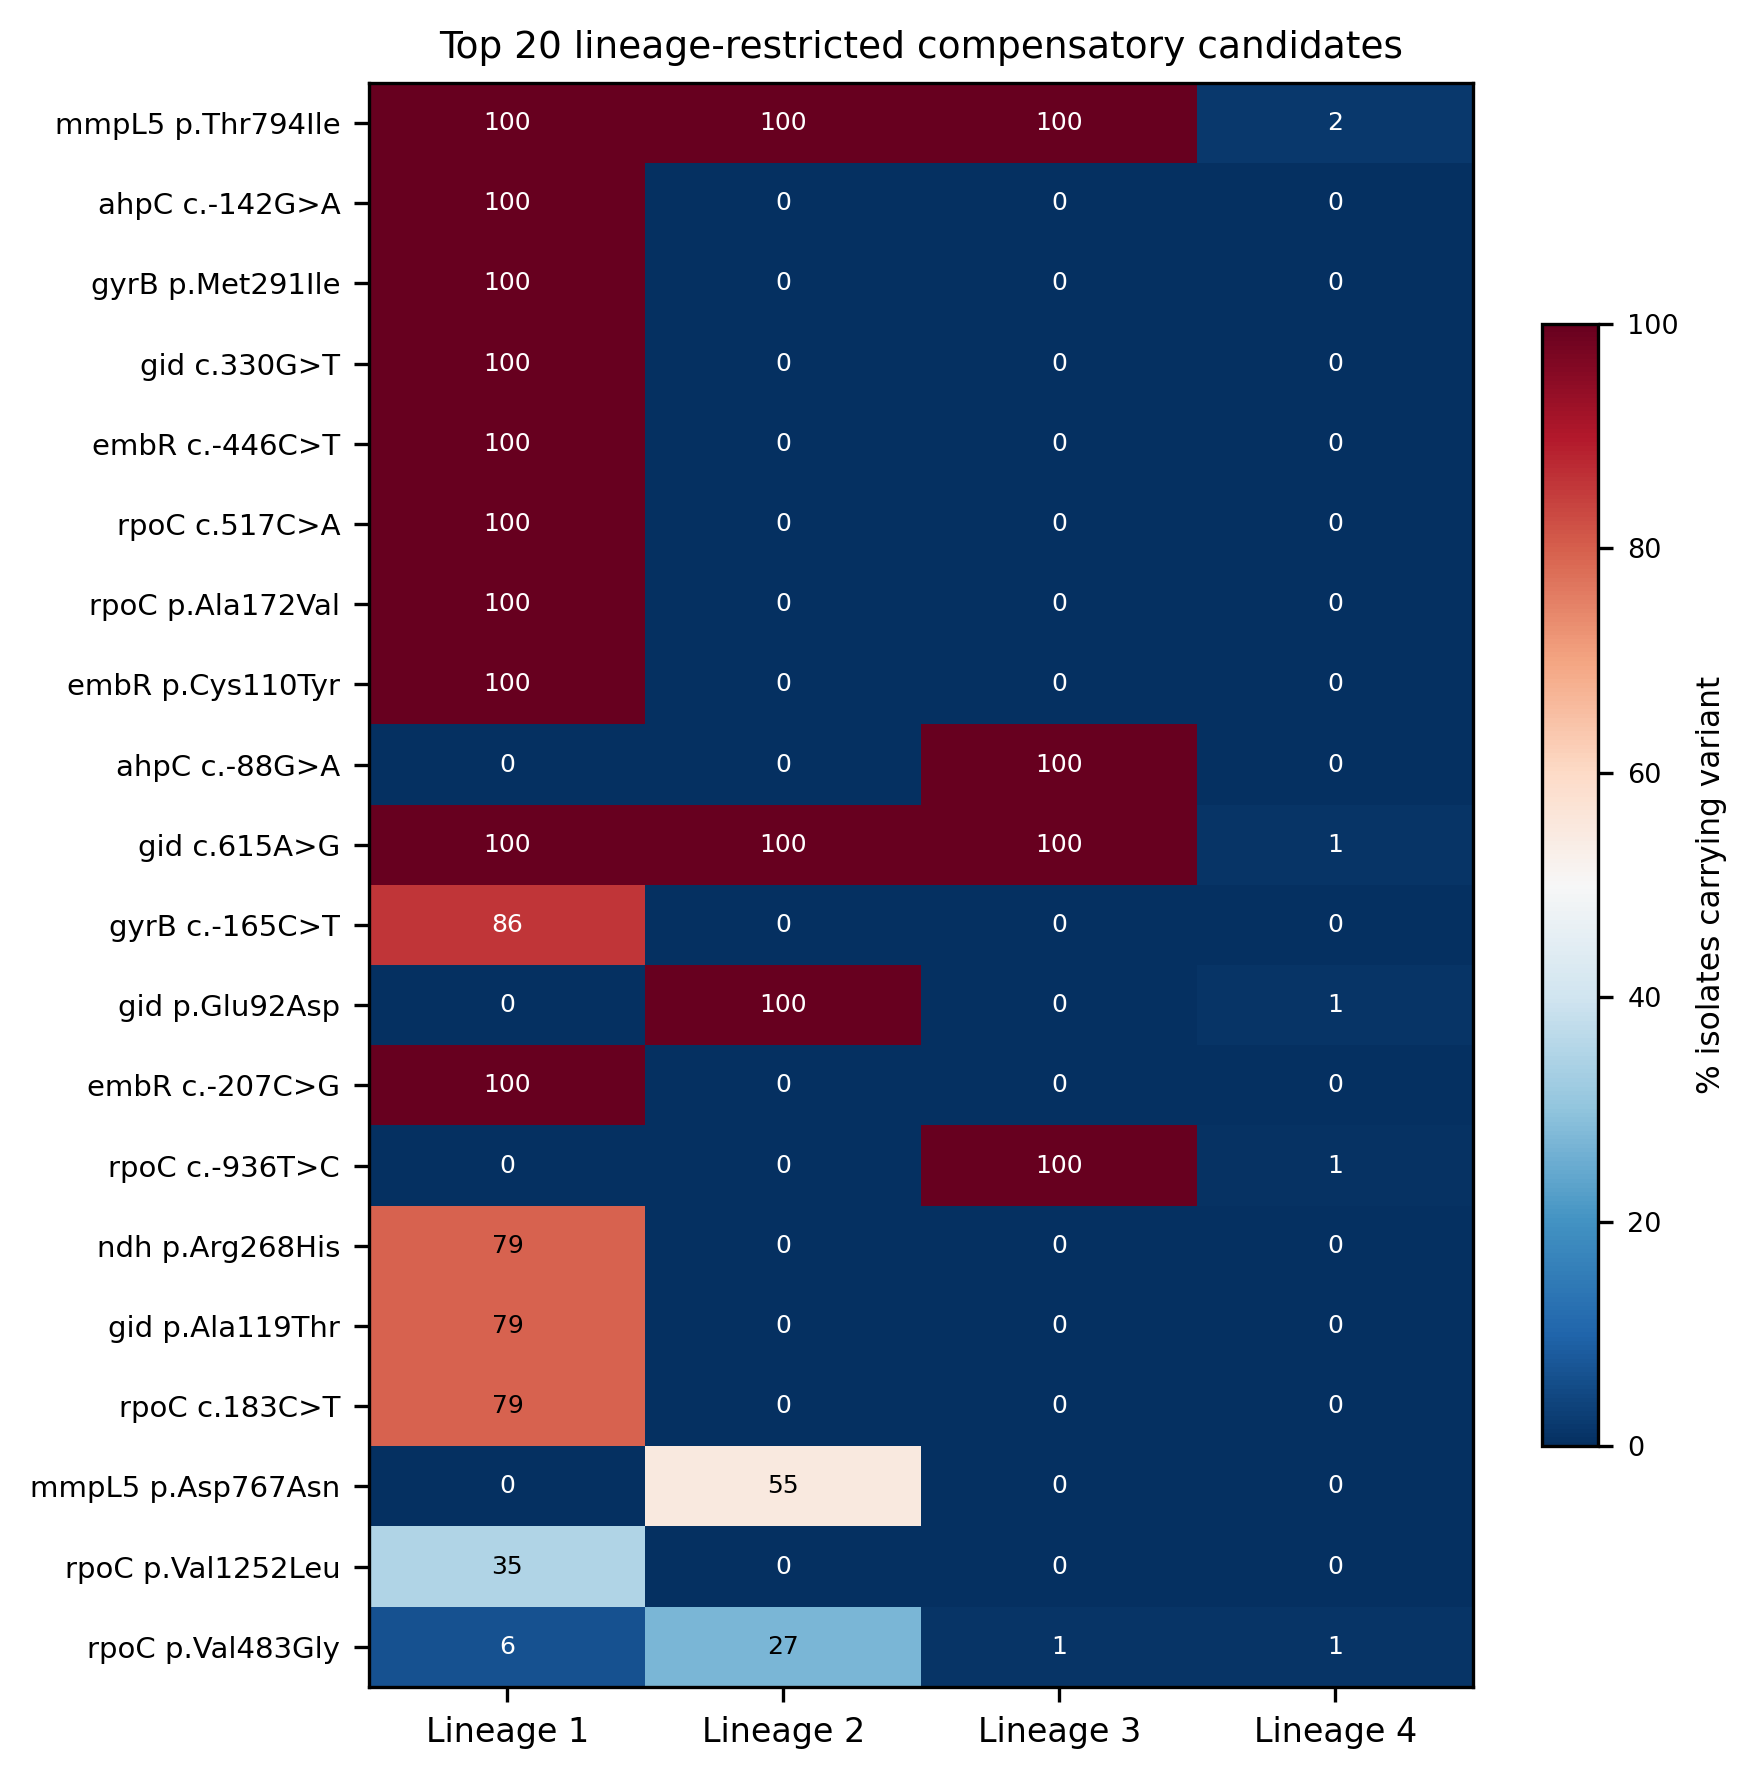

In [16]:
lineage = pd.read_csv(os.path.join(STEP8, "obj3_lineage_distribution.csv"))
top20_lin = lineage.sort_values("padj_lineage_BH").head(20).copy()
top20_lin["label"] = top20_lin["gene"] + " " + top20_lin["change"]
cols = ["carriage_pct_lineage1", "carriage_pct_lineage2", "carriage_pct_lineage3", "carriage_pct_lineage4"]
mat = top20_lin[cols].values

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(mat, cmap="RdBu_r", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["Lineage 1", "Lineage 2", "Lineage 3", "Lineage 4"], fontsize=8)
ax.set_yticks(range(len(top20_lin)))
ax.set_yticklabels(top20_lin["label"], fontsize=7)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center", fontsize=6,
                color="white" if abs(mat[i, j] - 50) > 30 else "black")
cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("% isolates carrying variant", fontsize=7.5)
cbar.ax.tick_params(labelsize=6.5)
ax.set_title("Top 20 lineage-restricted compensatory candidates", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "figS1_lineage_heatmap.png"))
plt.show()


## Figure S2 - Gene-Wide, Tree-Corrected dN/dS

All 9 compensatory-panel genes with observable coding variation (Step 9); the 3 genes with zero observed coding variants (mmpR5, whiB7, eis) are correctly omitted.

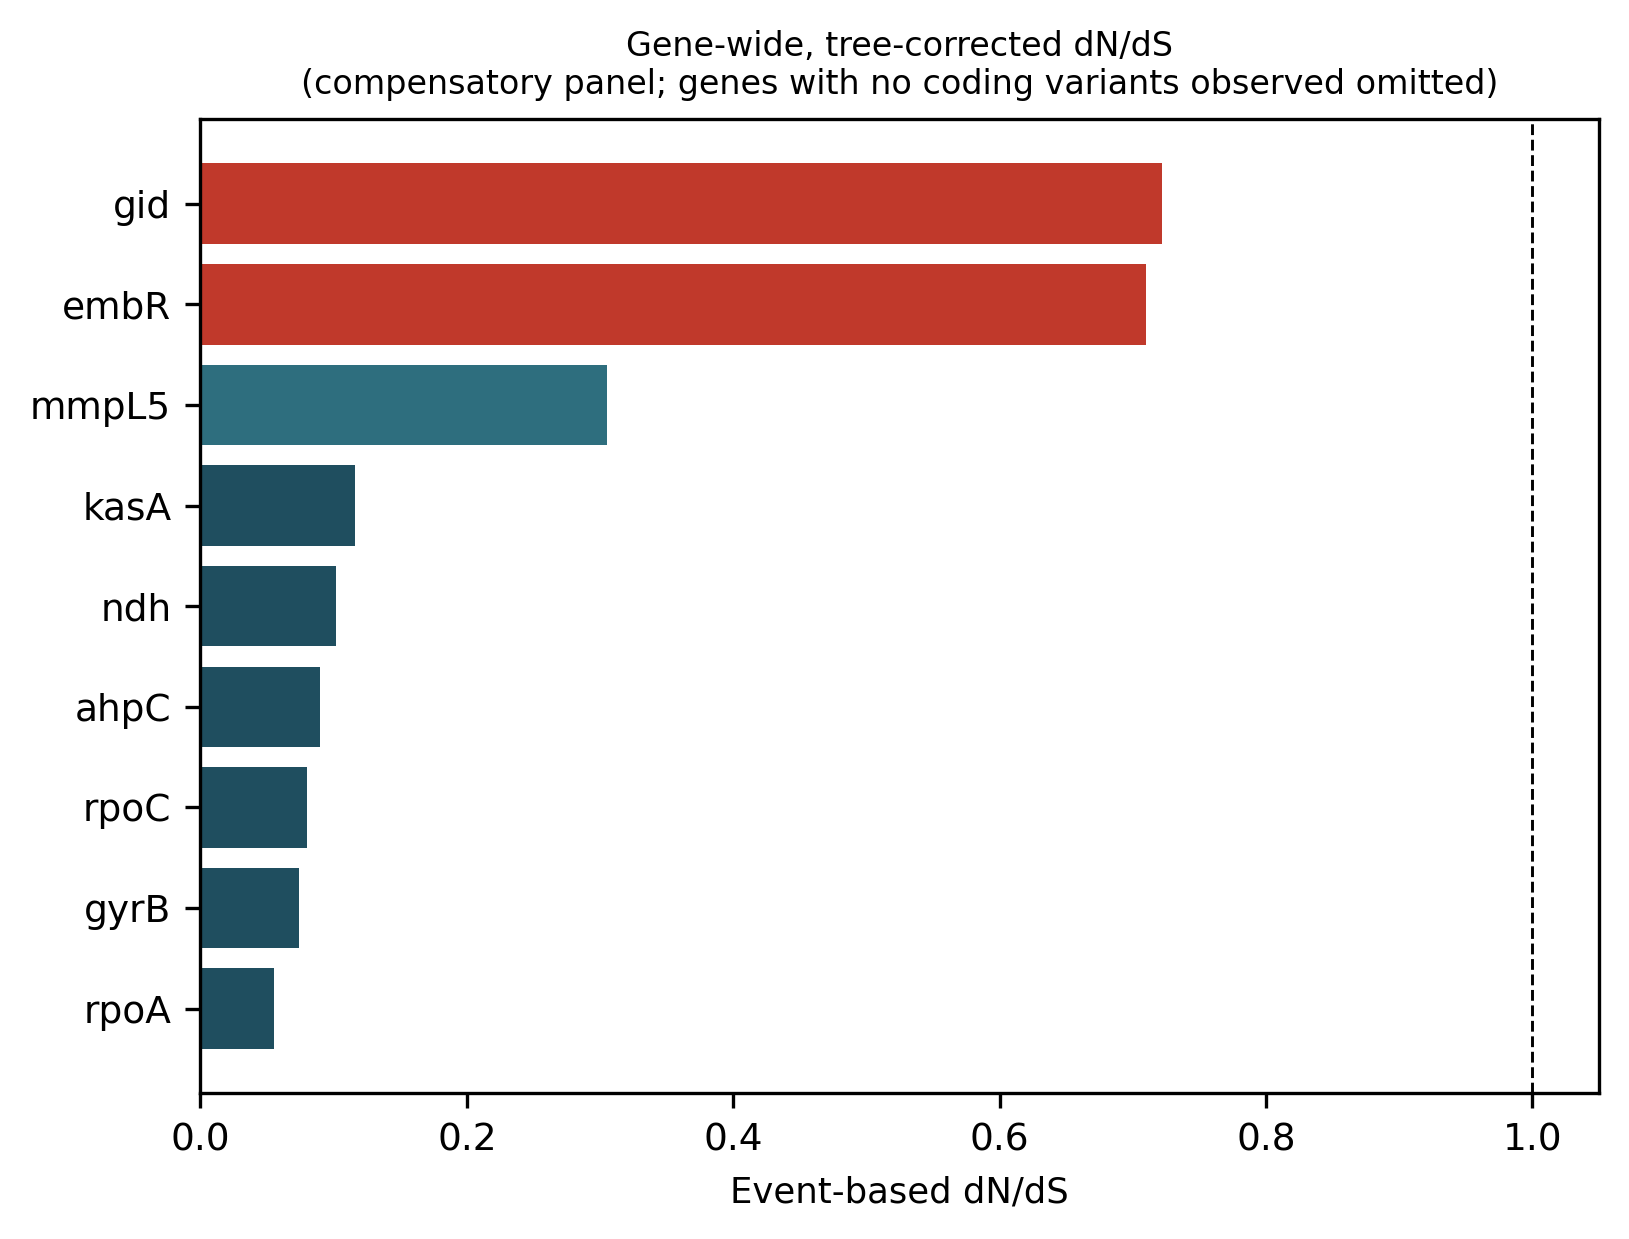

In [17]:
dnds = pd.read_csv(os.path.join(STEP9, "obj3_step9_gene_dNdS.csv"))
plot_df = dnds[dnds["N_events_fitch_sum"] + dnds["S_events_fitch_sum"] > 0].copy()
plot_df["dN_dS_event_based"] = pd.to_numeric(plot_df["dN_dS_event_based"], errors="coerce")
plot_df = plot_df.dropna(subset=["dN_dS_event_based"]).sort_values("dN_dS_event_based")

def color_for(v):
    if v > 0.5: return CORAL
    if v > 0.2: return TEAL
    return NAVY

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.barh(plot_df["gene"], plot_df["dN_dS_event_based"], color=[color_for(v) for v in plot_df["dN_dS_event_based"]])
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.7)
ax.set_xlabel("Event-based dN/dS", fontsize=8.5)
ax.set_title("Gene-wide, tree-corrected dN/dS\n(compensatory panel; genes with no coding variants observed omitted)", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "figS2_gene_dNdS.png"))
plt.show()


## Figure S3 - EBM Top Interaction Terms

The 7 real interaction terms found in Step 6's EBM analysis, each shown as a 2x2 grid of the term's contribution to the model's log-odds output at every combination of the two variants' presence/absence.

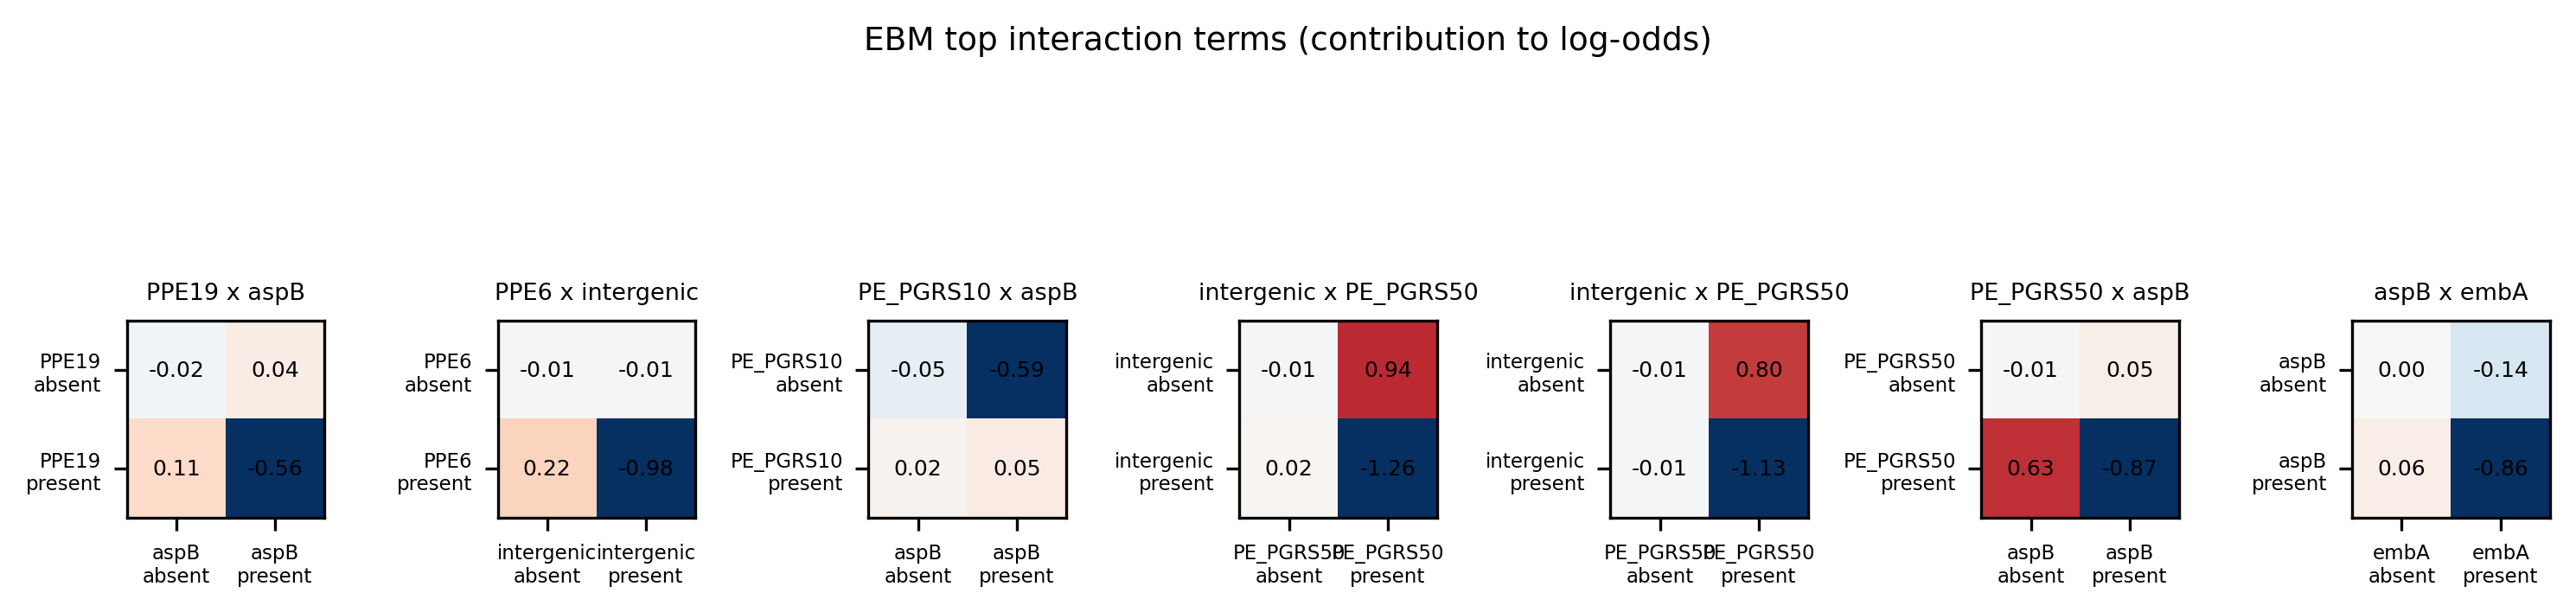

In [18]:
ebm_int = pd.read_csv(os.path.join(STEP6, "obj2_ebm_interactions_annotated.csv"))
top7 = ebm_int.sort_values("importance", ascending=False).head(7).copy()
top7["pair_label"] = top7["gene_a"] + " x " + top7["gene_b"]

fig, axes = plt.subplots(1, len(top7), figsize=(10, 2.4))
for ax, (_, row) in zip(axes, top7.iterrows()):
    mat = np.array([[row["score_both_absent"], row["score_B_only"]],
                     [row["score_A_only"], row["score_both_present"]]])
    vmax = np.abs(mat).max()
    ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=6)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels([f"{row['gene_b']}\nabsent", f"{row['gene_b']}\npresent"], fontsize=5.5)
    ax.set_yticklabels([f"{row['gene_a']}\nabsent", f"{row['gene_a']}\npresent"], fontsize=5.5)
    ax.set_title(row["pair_label"], fontsize=6.5)
fig.suptitle("EBM top interaction terms (contribution to log-odds)", fontsize=9, y=1.08)
plt.tight_layout()
plt.savefig(os.path.join(STEP12, "figS3_ebm_interactions.png"))
plt.show()


## Figure S4 - Structural Burial and Biochemical Severity Distributions

Distribution of relative solvent accessibility (A) and Grantham biochemical distance (B) across all real nonsynonymous candidates (Step 10) — this specific pair of distribution plots did not exist as a figure before this notebook.

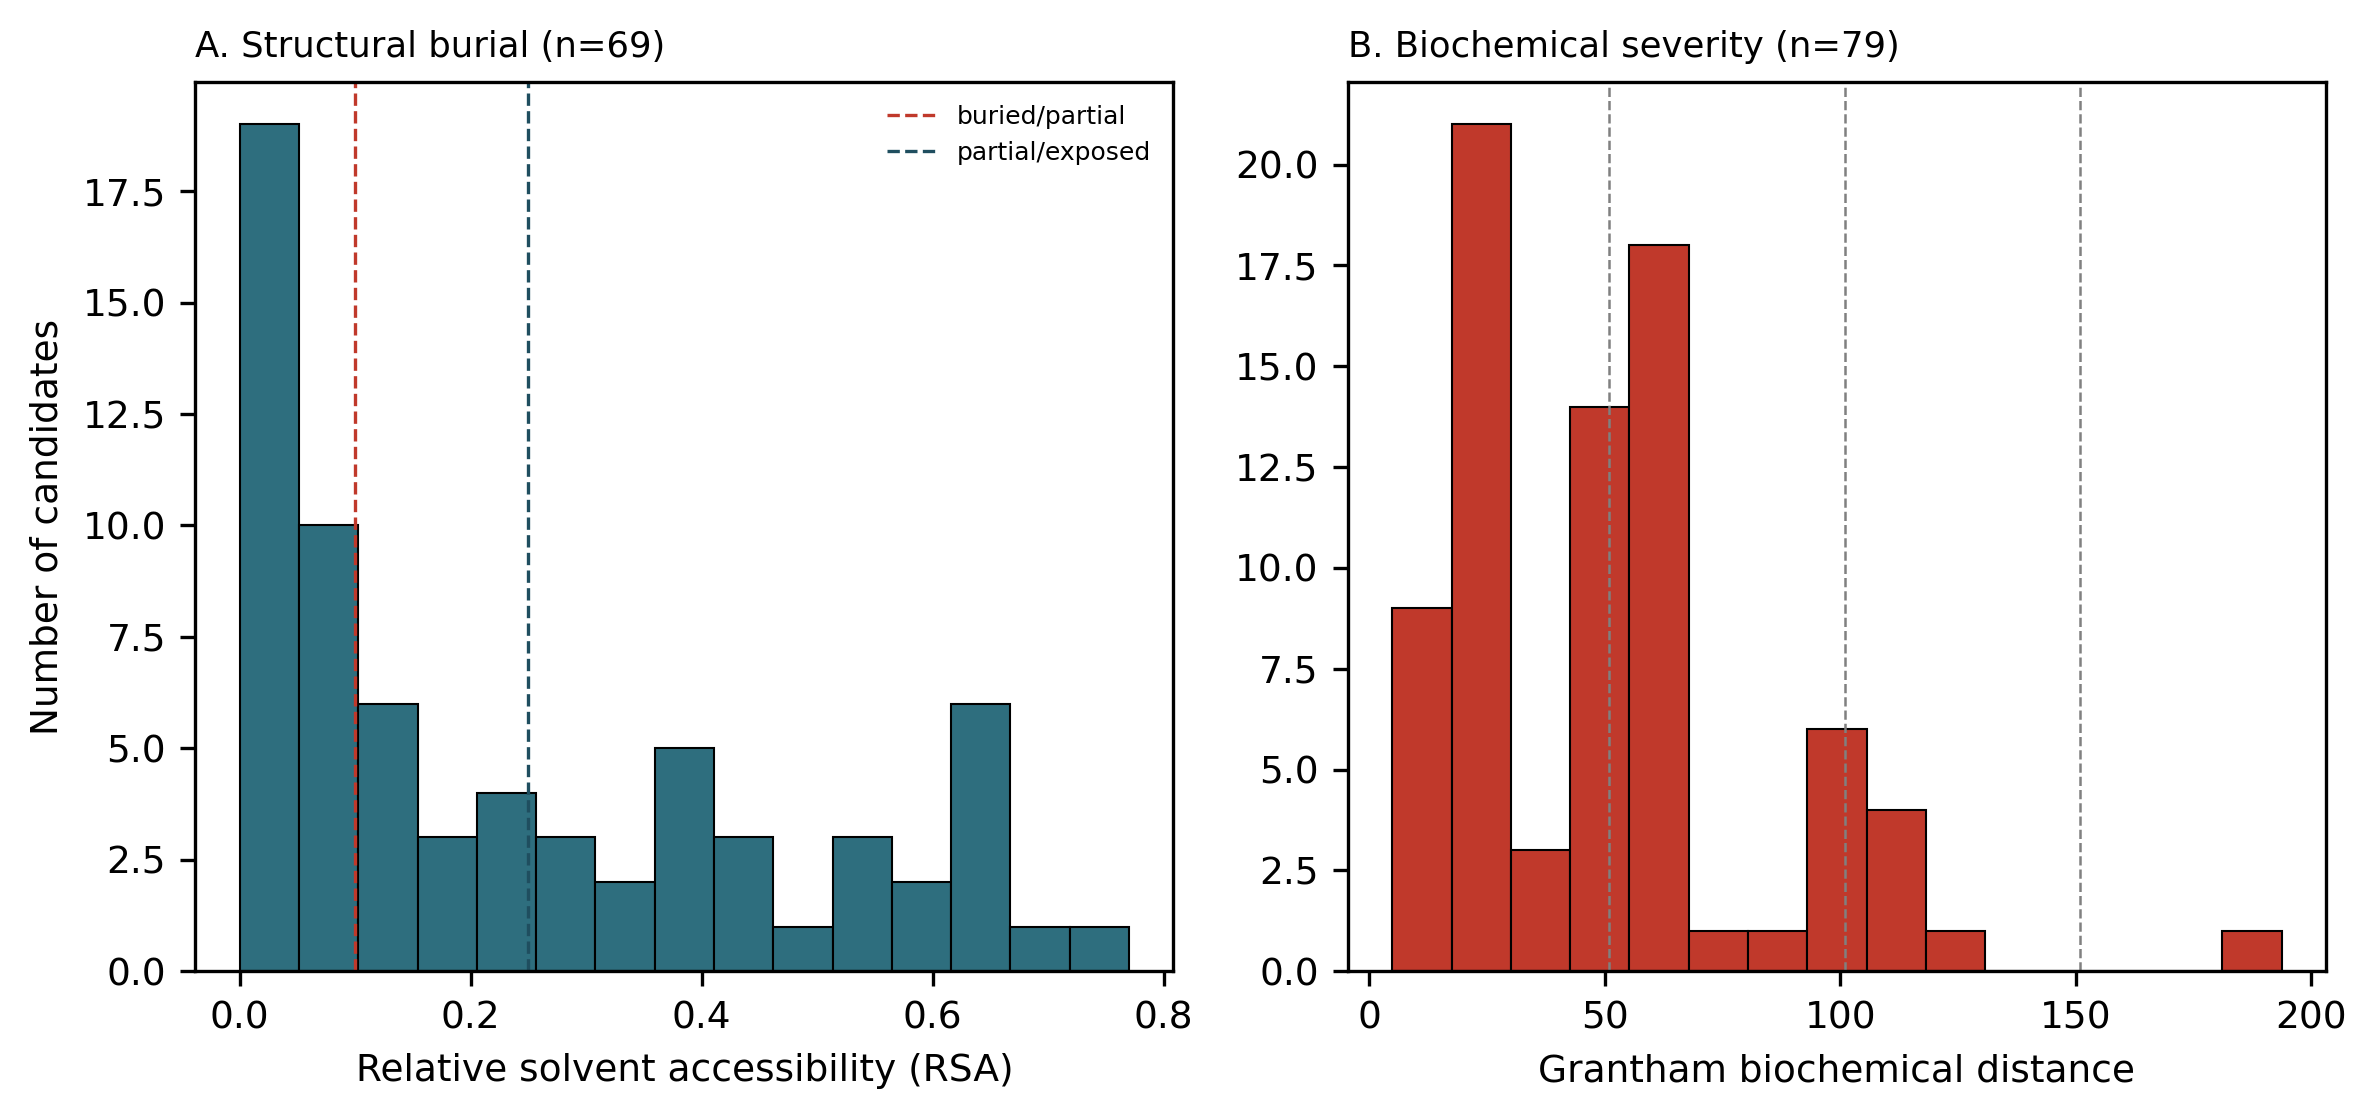

In [19]:
struct = pd.read_csv(os.path.join(STEP10, "obj3_step10_structural_context.csv"))
nonsyn = struct[struct["coding_classification"] == "nonsynonymous"].copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

rsa_vals = nonsyn["rsa"].dropna()
axes[0].hist(rsa_vals, bins=15, color=TEAL, edgecolor="black", linewidth=0.5)
axes[0].axvline(0.10, color=CORAL, linestyle="--", linewidth=0.8, label="buried/partial")
axes[0].axvline(0.25, color=NAVY, linestyle="--", linewidth=0.8, label="partial/exposed")
axes[0].set_xlabel("Relative solvent accessibility (RSA)")
axes[0].set_ylabel("Number of candidates")
axes[0].set_title(f"A. Structural burial (n={len(rsa_vals)})", fontsize=8.5, loc="left")
axes[0].legend(fontsize=6, frameon=False)

gr_vals = nonsyn["grantham_distance"].dropna()
axes[1].hist(gr_vals, bins=15, color=CORAL, edgecolor="black", linewidth=0.5)
for x in [51, 101, 151]:
    axes[1].axvline(x, color="gray", linestyle="--", linewidth=0.6)
axes[1].set_xlabel("Grantham biochemical distance")
axes[1].set_title(f"B. Biochemical severity (n={len(gr_vals)})", fontsize=8.5, loc="left")

plt.tight_layout()
plt.savefig(os.path.join(STEP12, "figS4_burial_severity.png"))
plt.show()


## Final Summary

9 figures total

**Main:** fig1_workflow_overview, fig2_volcano_plot, fig3_roc_curves, fig4_shap_summary, fig5_integrated_evidence

**Supplementary:** figS1_lineage_heatmap, figS2_gene_dNdS, figS3_ebm_interactions, figS4_burial_severity